# P2 — Exploratory analysis

Every plot here should either kill or justify a candidate feature for P5. The gate is the
hypothesis table at the end, not the figure count.

**Invariant:** all analysis in this notebook is computed on `d_1`-`d_1913` only. Plotting the
`d_1914`-`d_1941` holdout is a subtle form of peeking - it would shape feature choices around data
we've promised not to use. The load step below filters to the training range at read time so the
holdout is never materialized in this notebook at all.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import MSTL

DATA_DIR = Path("..") / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = Path("..") / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = 1913  # d_1914-d_1941 is the holdout (invariant 1).

sns.set_theme(style="whitegrid")

## Load: sales_long.parquet, training range only

`sales_long.parquet` spans the full calendar (`d_1`-`d_1941`) - P1 only dropped pre-release rows,
not the `d_1914`-`d_1941` holdout. Filter to `d <= TRAIN_END` at read time via pyarrow predicate
pushdown, so the holdout rows are never read off disk into this notebook, rather than loading the
full frame and filtering after (which is exactly the mistake fixed in P1's negative-sales and
sparsity checks).

In [2]:
sales_long = pd.read_parquet(
    PROCESSED_DIR / "sales_long.parquet",
    filters=[("d", "<=", TRAIN_END)],
)

assert sales_long["d"].max() <= TRAIN_END, \
    f"holdout leaked into the loaded frame: max d = {sales_long['d'].max()}"

n_unique_dates = sales_long["date"].nunique()
assert n_unique_dates == TRAIN_END, \
    f"expected {TRAIN_END} unique dates, got {n_unique_dates}"

print(f"loaded: {len(sales_long):,} rows, {sales_long.shape[1]} columns")
print(f"date range: {sales_long['date'].min().date()} to {sales_long['date'].max().date()}")
print(f"unique dates: {n_unique_dates:,}")
print(f"memory usage: {sales_long.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
sales_long.dtypes

loaded: 46,027,957 rows, 22 columns


date range: 2011-01-29 to 2016-04-24
unique dates: 1,913
memory usage: 1,753.0 MB


id                    category
item_id               category
dept_id               category
cat_id                category
store_id              category
state_id              category
sales                    int16
date            datetime64[ns]
wm_yr_wk                 int16
weekday               category
wday                      int8
month                     int8
year                     int16
d                        int16
event_name_1          category
event_type_1          category
event_name_2          category
event_type_2          category
snap_CA                   int8
snap_TX                   int8
snap_WI                   int8
sell_price             float32
dtype: object

## Trend and level

We decompose the total daily units series with `statsmodels`' `MSTL` (multiple-seasonal STL) into
a trend component plus weekly (period=7) and annual (period=365) seasonal components. This gives
an explicit trend line net of both seasonal cycles, rather than eyeballing a rolling average.

The question that matters for P5: is the extracted trend **real demand** (more units sold per
already-listed item) or **assortment expansion** (more items added to the catalog over time)?
MSTL's trend component alone can't distinguish these — it decomposes the *raw* total, so catalog
growth shows up as "trend" too. We still need the units-per-active-series comparison below to
separate them.

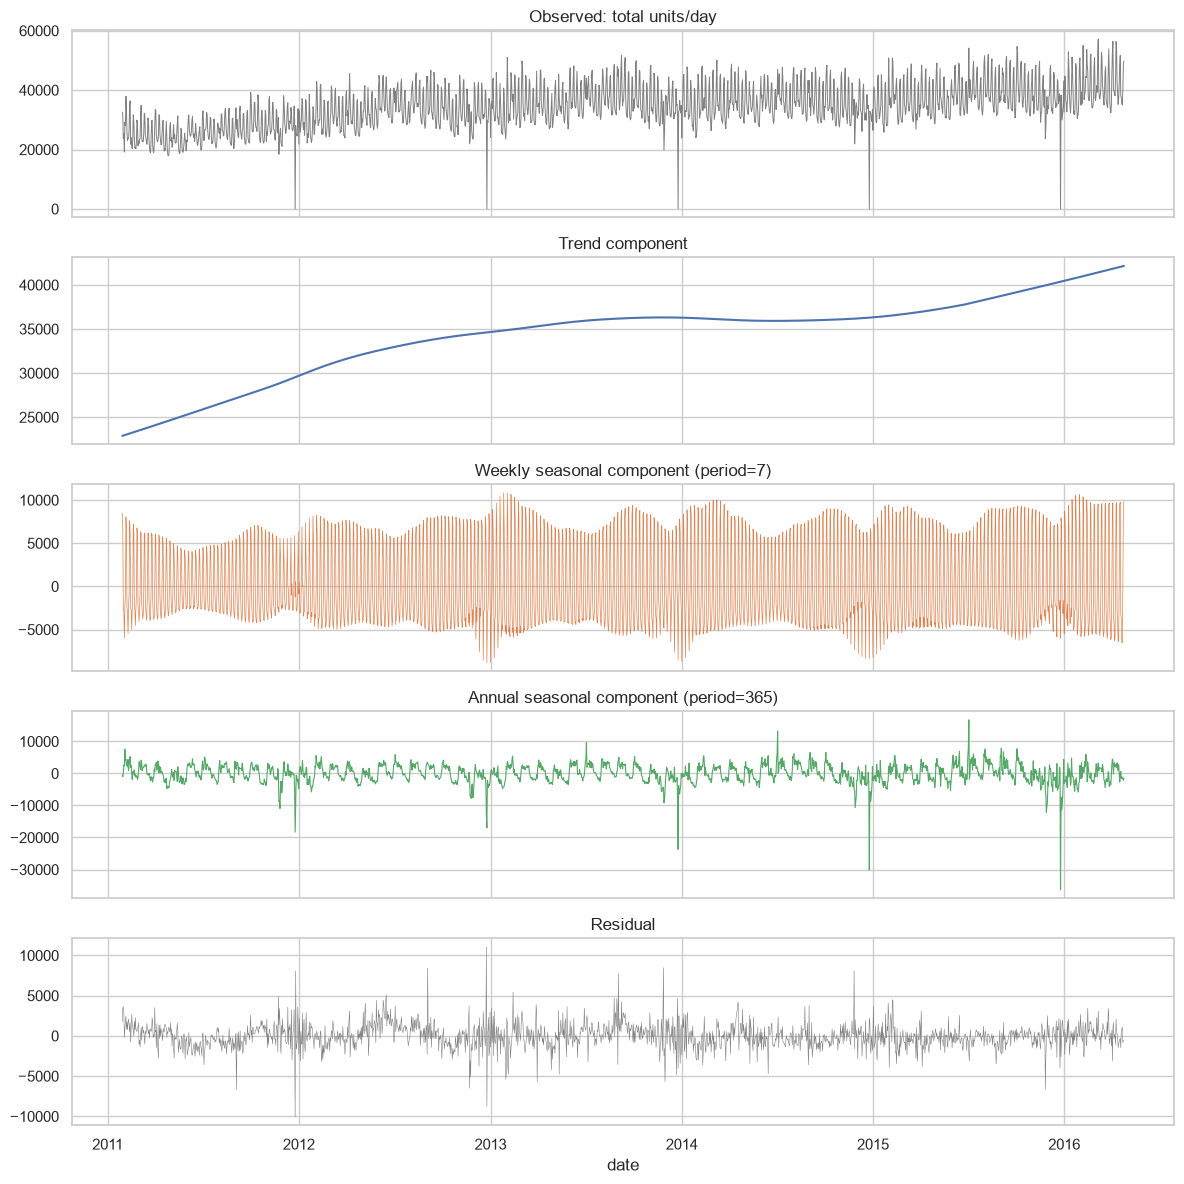

MSTL trend component, first 28d avg -> last 28d avg: +81.3%


In [3]:
daily_total = (
    sales_long.groupby("date", observed=True)["sales"]
    .sum()
    .rename("units")
    .to_frame()
)
daily_total_series = daily_total["units"].asfreq("D")

mstl_total = MSTL(daily_total_series, periods=(7, 365)).fit()

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(mstl_total.observed, color="grey", lw=0.7)
axes[0].set_title("Observed: total units/day")
axes[1].plot(mstl_total.trend, color="C0")
axes[1].set_title("Trend component")
axes[2].plot(mstl_total.seasonal["seasonal_7"], color="C1", lw=0.5)
axes[2].set_title("Weekly seasonal component (period=7)")
axes[3].plot(mstl_total.seasonal["seasonal_365"], color="C2", lw=0.8)
axes[3].set_title("Annual seasonal component (period=365)")
axes[4].plot(mstl_total.resid, color="grey", lw=0.4)
axes[4].set_title("Residual")
axes[4].set_xlabel("date")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_mstl_decomposition.png", dpi=150)
plt.show()

trend_growth_pct = mstl_total.trend.iloc[-28:].mean() / mstl_total.trend.iloc[:28].mean() - 1
print(f"MSTL trend component, first 28d avg -> last 28d avg: {trend_growth_pct:+.1%}")

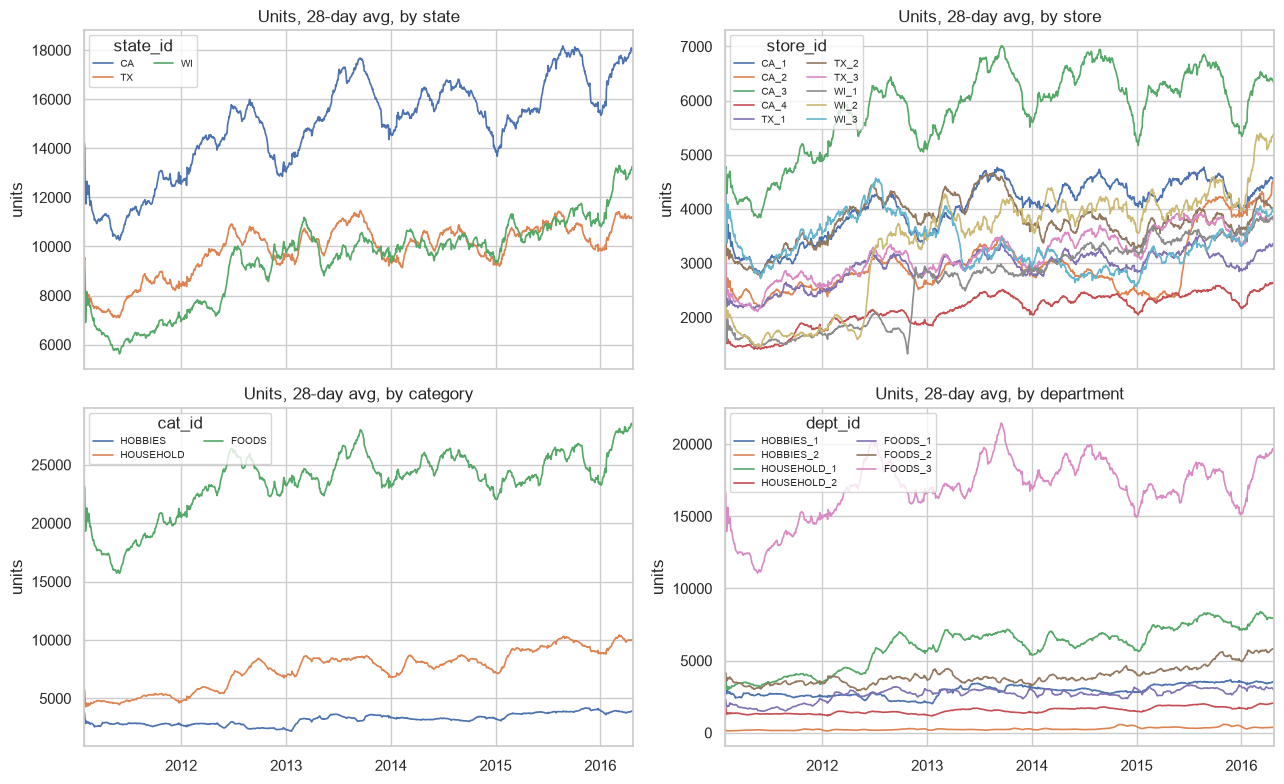

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

for ax, (level, title) in zip(
    axes.flat,
    [
        ("state_id", "by state"),
        ("store_id", "by store"),
        ("cat_id", "by category"),
        ("dept_id", "by department"),
    ],
):
    grp = (
        sales_long.groupby(["date", level], observed=True)["sales"]
        .sum()
        .unstack(level)
    )
    grp_28d = grp.rolling(28, min_periods=1).mean()
    grp_28d.plot(ax=ax, lw=1.2, legend=True)
    ax.set_title(f"Units, 28-day avg, {title}")
    ax.set_xlabel("")
    ax.set_ylabel("units")
    ax.legend(title=level, fontsize=7, ncol=2, loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_by_level.png", dpi=150)
plt.show()

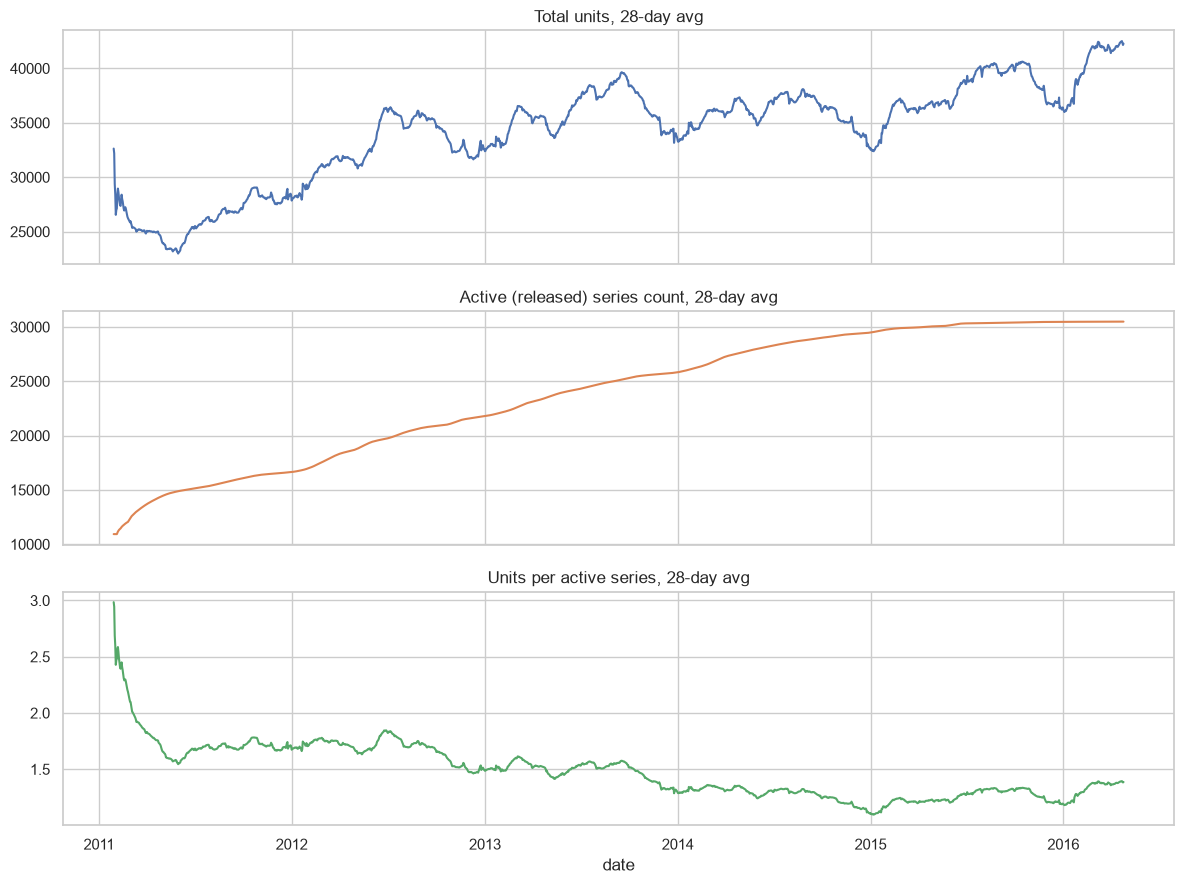

first 28d -> last 28d of training range:
  total units:          +61.1%
  active series count:  +152.9%
  units per active series: -36.7%


In [5]:
# P1 dropped pre-release rows, so a row's mere presence on a date means that series was
# listed (active) that day - counting rows per date gives assortment size directly.
active_series = sales_long.groupby("date", observed=True)["id"].nunique().rename("n_active_series")

assortment = daily_total[["units"]].join(active_series)
assortment["units_per_active_series"] = assortment["units"] / assortment["n_active_series"]
assortment_28d = assortment.rolling(28, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(assortment_28d.index, assortment_28d["units"], color="C0")
axes[0].set_title("Total units, 28-day avg")
axes[1].plot(assortment_28d.index, assortment_28d["n_active_series"], color="C1")
axes[1].set_title("Active (released) series count, 28-day avg")
axes[2].plot(assortment_28d.index, assortment_28d["units_per_active_series"], color="C2")
axes[2].set_title("Units per active series, 28-day avg")
axes[2].set_xlabel("date")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_assortment.png", dpi=150)
plt.show()

pct_change_units = assortment["units"].iloc[-28:].mean() / assortment["units"].iloc[:28].mean() - 1
pct_change_series = assortment["n_active_series"].iloc[-28:].mean() / assortment["n_active_series"].iloc[:28].mean() - 1
pct_change_per_series = assortment["units_per_active_series"].iloc[-28:].mean() / assortment["units_per_active_series"].iloc[:28].mean() - 1
print(f"first 28d -> last 28d of training range:")
print(f"  total units:          {pct_change_units:+.1%}")
print(f"  active series count:  {pct_change_series:+.1%}")
print(f"  units per active series: {pct_change_per_series:+.1%}")

## Seasonality

We run `MSTL` per category (FOODS, HOBBIES, HOUSEHOLD) on raw daily units, same as the trend
section, then read the weekly and annual seasonal components off each fit. Expressing each
seasonal component as a fraction of that category's own MSTL trend (`seasonal / trend`) gives a
lift-relative-to-level number per day/month, which is directly comparable to the "% lift" language
the hypothesis table wants — and, because it's computed against MSTL's own trend line rather than
a manual units-per-active-series ratio, the assortment-growth confound is already handled by the
decomposition itself.

The brief calls out that weekend lift is strong and differs between FOODS and HOBBIES, so we keep
the per-category split rather than decomposing the aggregate.

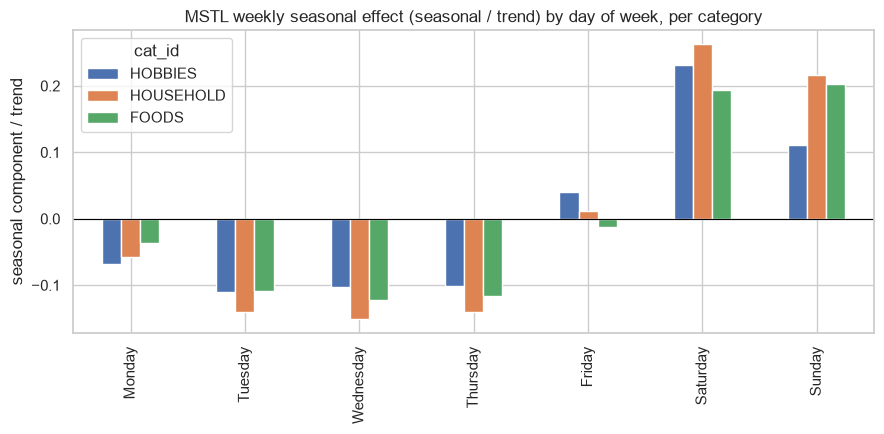

weekend seasonal effect minus weekday seasonal effect (pct points of trend):


HOUSEHOLD    0.334950
FOODS        0.276879
HOBBIES      0.239408
dtype: float64

In [6]:
category_daily = (
    sales_long.groupby(["date", "cat_id"], observed=True)["sales"]
    .sum()
    .unstack("cat_id")
    .asfreq("D")
)

cat_mstl = {cat: MSTL(category_daily[cat], periods=(7, 365)).fit() for cat in category_daily.columns}

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_effect = {}
for cat, result in cat_mstl.items():
    seasonal_pct = result.seasonal["seasonal_7"] / result.trend
    dow_effect[cat] = seasonal_pct.groupby(seasonal_pct.index.day_name()).mean().reindex(weekday_order)
dow_effect_df = pd.DataFrame(dow_effect)

fig, ax = plt.subplots(figsize=(9, 4.5))
dow_effect_df.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("MSTL weekly seasonal effect (seasonal / trend) by day of week, per category")
ax.set_xlabel("")
ax.set_ylabel("seasonal component / trend")
ax.legend(title="cat_id")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "seasonality_dow_mstl.png", dpi=150)
plt.show()

weekend_lift_mstl = (
    dow_effect_df.loc[["Saturday", "Sunday"]].mean()
    - dow_effect_df.loc[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]].mean()
)
print("weekend seasonal effect minus weekday seasonal effect (pct points of trend):")
weekend_lift_mstl.sort_values(ascending=False)

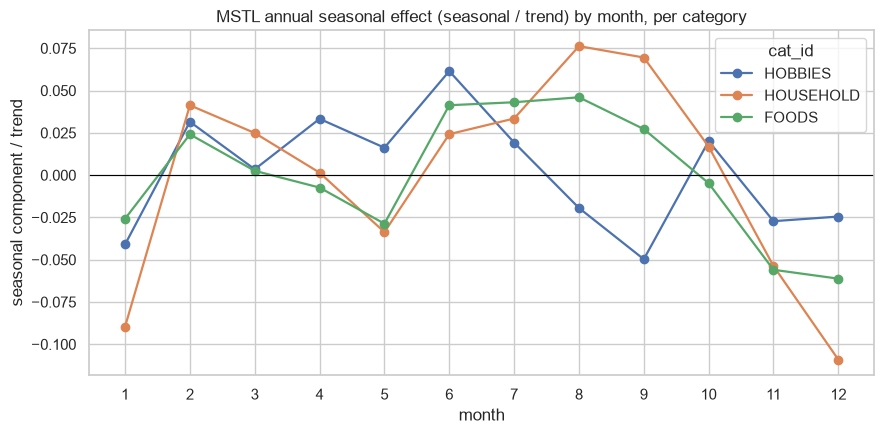

annual seasonal effect range by category:


,peak_month,trough_month,peak_minus_trough_pct_pts
HOBBIES,6,9,0.111208
HOUSEHOLD,8,12,0.185321
FOODS,8,12,0.107229


In [7]:
annual_effect = {}
for cat, result in cat_mstl.items():
    seasonal_pct = result.seasonal["seasonal_365"] / result.trend
    annual_effect[cat] = seasonal_pct.groupby(seasonal_pct.index.month).mean()
annual_effect_df = pd.DataFrame(annual_effect)

fig, ax = plt.subplots(figsize=(9, 4.5))
annual_effect_df.plot(ax=ax, marker="o", lw=1.6)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("MSTL annual seasonal effect (seasonal / trend) by month, per category")
ax.set_xlabel("month")
ax.set_ylabel("seasonal component / trend")
ax.set_xticks(range(1, 13))
ax.legend(title="cat_id")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "seasonality_month_mstl.png", dpi=150)
plt.show()

peak_trough_mstl = pd.DataFrame({
    "peak_month": annual_effect_df.idxmax(),
    "trough_month": annual_effect_df.idxmin(),
    "peak_minus_trough_pct_pts": annual_effect_df.max() - annual_effect_df.min(),
})
print("annual seasonal effect range by category:")
peak_trough_mstl

## SNAP

SNAP (food-stamp) disbursement days are state-specific — `calendar.csv` gives a separate flag per
state (`snap_CA`, `snap_TX`, `snap_WI`), and each state has its own schedule within the month. The
brief flags this as one of the highest-value features in the dataset, worth a proper effect size
rather than a glance, and expects the lift to show up specifically in FOODS (SNAP benefits are for
food purchases).

We isolate the SNAP effect the same way as the day-of-week effect: fit `MSTL` per state on daily
FOODS units to remove the weekly and annual seasonal cycles, then compare the residual-over-trend
ratio (`resid / trend`) on SNAP vs. non-SNAP days. Using the residual rather than the raw or
seasonally-naive average keeps a state's SNAP schedule (which correlates with day-of-week within
the month) from being counted as day-of-week seasonality instead of a SNAP effect.

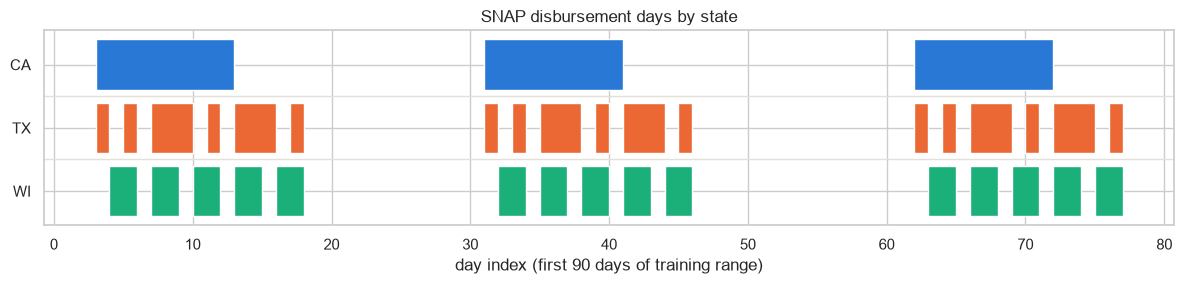

In [8]:
snap_schedule = (
    sales_long[["date", "snap_CA", "snap_TX", "snap_WI"]]
    .drop_duplicates("date")
    .set_index("date")
    .sort_index()
    .iloc[:90]
)

# Fixed categorical order/hues (dataviz skill palette, slots 1-3): distinguishable
# under color-vision deficiency, unlike the single-hue grayscale imshow version.
state_colors = {"CA": "#2a78d6", "TX": "#eb6834", "WI": "#1baf7a"}
row_y = {"CA": 2, "TX": 1, "WI": 0}

fig, ax = plt.subplots(figsize=(12, 3))
for state, y in row_y.items():
    flags = snap_schedule[f"snap_{state}"].to_numpy()
    runs, start = [], None
    for i, v in enumerate(flags):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            runs.append((start, i - start))
            start = None
    if start is not None:
        runs.append((start, len(flags) - start))
    ax.broken_barh(runs, (y + 0.1, 0.8), facecolors=state_colors[state])

ax.set_yticks([y + 0.5 for y in row_y.values()])
ax.set_yticklabels(list(row_y.keys()))
for y in (1, 2):
    ax.axhline(y, color="#e1e0d9", lw=1)  # row separators, at boundaries not centers
ax.set_xlabel("day index (first 90 days of training range)")
ax.set_title("SNAP disbursement days by state")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "snap_schedule.png", dpi=150)
plt.show()

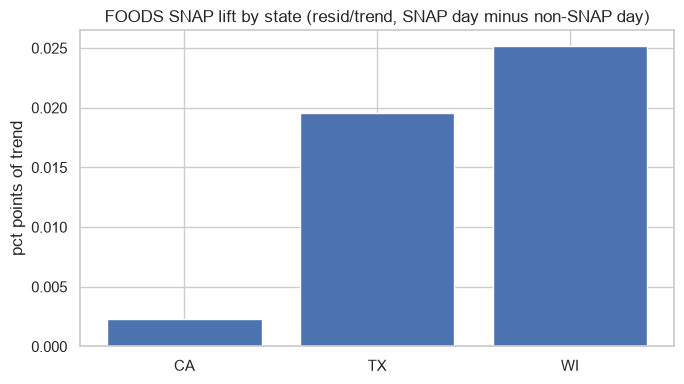

FOODS SNAP effect size by state:


,non_snap_effect,snap_effect,snap_lift_pct_pts
WI,-0.009813,0.015403,0.025215
TX,-0.004730,0.014807,0.019537
CA,0.000176,0.002457,0.002281


In [9]:
foods_state_daily = (
    sales_long[sales_long["cat_id"] == "FOODS"]
    .groupby(["date", "state_id"], observed=True)["sales"]
    .sum()
    .unstack("state_id")
    .asfreq("D")
)

state_mstl = {state: MSTL(foods_state_daily[state], periods=(7, 365)).fit() for state in foods_state_daily.columns}

snap_col = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}
snap_by_date = (
    sales_long[["date", "snap_CA", "snap_TX", "snap_WI"]]
    .drop_duplicates("date")
    .set_index("date")
)

snap_lift = {}
for state, result in state_mstl.items():
    resid_pct = result.resid / result.trend
    snap_flag = snap_by_date[snap_col[state]].reindex(resid_pct.index)
    grp = resid_pct.groupby(snap_flag).mean()
    snap_lift[state] = {
        "non_snap_effect": grp.loc[0],
        "snap_effect": grp.loc[1],
        "snap_lift_pct_pts": grp.loc[1] - grp.loc[0],
    }
snap_lift_df = pd.DataFrame(snap_lift).T

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(snap_lift_df.index, snap_lift_df["snap_lift_pct_pts"], color="C0")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("FOODS SNAP lift by state (resid/trend, SNAP day minus non-SNAP day)")
ax.set_ylabel("pct points of trend")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "snap_lift_by_state.png", dpi=150)
plt.show()

print("FOODS SNAP effect size by state:")
snap_lift_df.sort_values("snap_lift_pct_pts", ascending=False)